# EV Charging Dynamic Tariff Optimization System

This notebook orchestrates the end-to-end simulation pipeline.

In [53]:
import os
import sys
# Add parent directory to path to import src and config
sys.path.append(os.path.abspath('..'))

from main import run_simulation
run_simulation()

[DataLoader] Loaded 1706 stations from CSV.
[DataLoader] Reading and repairing ACN-Data JSON file...
[DataLoader] Loaded 14299 charging sessions from JSON.
[Preprocessing] Aggregated sessions into 5215 hourly steps.
[Main] Split data: Train=4463 hours, Eval=752 hours.
[DemandPredictionAgent] Trained on 4463 hourly samples. Global avg kwh: 25.77

      SIMULATION RESULTS COMPARISON SUMMARY
Evaluation Hours            : 752
Total Energy Delivered      : 13388.59 kWh
Static Revenue ($0.25/kWh)  : $3347.15
Dynamic Tariff Revenue      : $3397.05
Net Revenue Lift            : $49.90 (1.49%)
Average Grid Utilization    : 0.11
Average User Satisfaction   : 0.97
Demand Forecasting MAE      : 17.59 kWh
Demand Forecasting RMSE     : 27.47 kWh

[Evaluator] Saved simulation report chart to C:/projects_antig/notebooks/simulation_report.png
[Main] Copied report chart to brain artifacts directory.


# EV Charging Dynamic Tariff Optimization System
This notebook provides a full analysis and simulation of the EV Charging Dynamic Tariff Optimization pipeline.

In [54]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))

from config.settings import STATIONS_CSV_PATH, ACNDATA_JSON_PATH
from src.data_loader import load_stations_data, load_sessions_data
from src.preprocessing import preprocess_sessions, aggregate_hourly
from src.models import DemandPredictionAgent, TariffPricingAgent, MonitoringLearningAgent
from src.evaluator import compute_kpis, plot_simulation_results

print("✅ All imports successful!")

✅ All imports successful!


## 1. Load Data

In [55]:
# Load stations
stations_df = load_stations_data()
print(f"✅ Stations loaded: {stations_df.shape}")
stations_df.head()

[DataLoader] Loaded 1706 stations from CSV.
✅ Stations loaded: (1706, 6)


,station_id,latitude,longitude,fast,slow,count
0,1,22.716272,113.826349,5,5,10
1,2,22.678851,114.049721,20,0,20
2,3,22.509541,114.058510,0,8,8
3,4,22.605970,114.122110,0,6,6
4,5,22.732771,113.816951,0,55,55


In [56]:
# Load sessions
sessions_df = load_sessions_data()
print(f"✅ Sessions loaded: {sessions_df.shape}")
sessions_df.head()

[DataLoader] Reading and repairing ACN-Data JSON file...
[DataLoader] Loaded 14299 charging sessions from JSON.
✅ Sessions loaded: (14299, 13)


,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs
0,5bc90cb9f9af8b0d7fe77cd2,0039,2018-04-25 11:08:04,2018-04-25 13:20:10,2018-04-25 13:21:10,7.932,2_39_78_362_2018-04-25 11:08:04.400812,0002,CA-496,2-39-78-362,America/Los_Angeles,None,None
1,5bc90cb9f9af8b0d7fe77cd3,0039,2018-04-25 13:45:10,2018-04-26 00:56:16,2018-04-25 16:44:15,10.013,2_39_95_27_2018-04-25 13:45:09.617470,0002,CA-319,2-39-95-27,America/Los_Angeles,None,None
2,5bc90cb9f9af8b0d7fe77cd4,0039,2018-04-25 13:45:50,2018-04-25 23:04:45,2018-04-25 14:51:44,5.257,2_39_79_380_2018-04-25 13:45:49.962001,0002,CA-489,2-39-79-380,America/Los_Angeles,None,None
3,5bc90cb9f9af8b0d7fe77cd5,0039,2018-04-25 14:37:06,2018-04-25 23:55:34,2018-04-25 16:05:22,5.177,2_39_79_379_2018-04-25 14:37:06.460772,0002,CA-327,2-39-79-379,America/Los_Angeles,None,None
4,5bc90cb9f9af8b0d7fe77cd6,0039,2018-04-25 14:40:34,2018-04-25 23:03:12,2018-04-25 17:40:30,10.119,2_39_79_381_2018-04-25 14:40:33.638896,0002,CA-490,2-39-79-381,America/Los_Angeles,None,None


## 2. Exploratory Data Analysis (EDA)

In [57]:
print("Sessions Info:")
print(sessions_df.info())
print("\nBasic Statistics:")
sessions_df.describe()

Sessions Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14299 entries, 0 to 14298
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   _id               14299 non-null  object        
 1   clusterID         14299 non-null  object        
 2   connectionTime    14299 non-null  datetime64[ns]
 3   disconnectTime    14299 non-null  datetime64[ns]
 4   doneChargingTime  14293 non-null  datetime64[ns]
 5   kWhDelivered      14299 non-null  float64       
 6   sessionID         14299 non-null  object        
 7   siteID            14299 non-null  object        
 8   spaceID           14299 non-null  object        
 9   stationID         14299 non-null  object        
 10  timezone          14299 non-null  object        
 11  userID            1639 non-null   object        
 12  userInputs        1639 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(9)
memory usage: 1.4

,connectionTime,disconnectTime,doneChargingTime,kWhDelivered
count,14299,14299,14293,14299.000000
mean,2018-08-13 20:45:11.731869184,2018-08-14 02:40:24.896776192,2018-08-13 23:55:01.025466880,8.980463
min,2018-04-25 11:08:04,2018-04-25 13:20:10,2018-04-25 13:21:10,0.501000
25%,2018-06-26 03:42:29,2018-06-26 13:47:53,2018-06-26 06:46:40,4.037500
50%,2018-08-17 04:44:36,2018-08-17 12:48:12,2018-08-17 06:55:26,7.473000
75%,2018-10-01 15:41:25,2018-10-01 23:51:03.500000,2018-10-01 20:03:03,13.204000
max,2018-11-28 17:52:50,2018-11-30 16:52:03,2018-11-29 22:59:24,69.373000
std,NaN,NaN,NaN,6.920977


In [58]:
print("Missing Values:")
missing = sessions_df.isnull().sum()
print(missing[missing > 0])

Missing Values:
doneChargingTime        6
userID              12660
userInputs          12660
dtype: int64


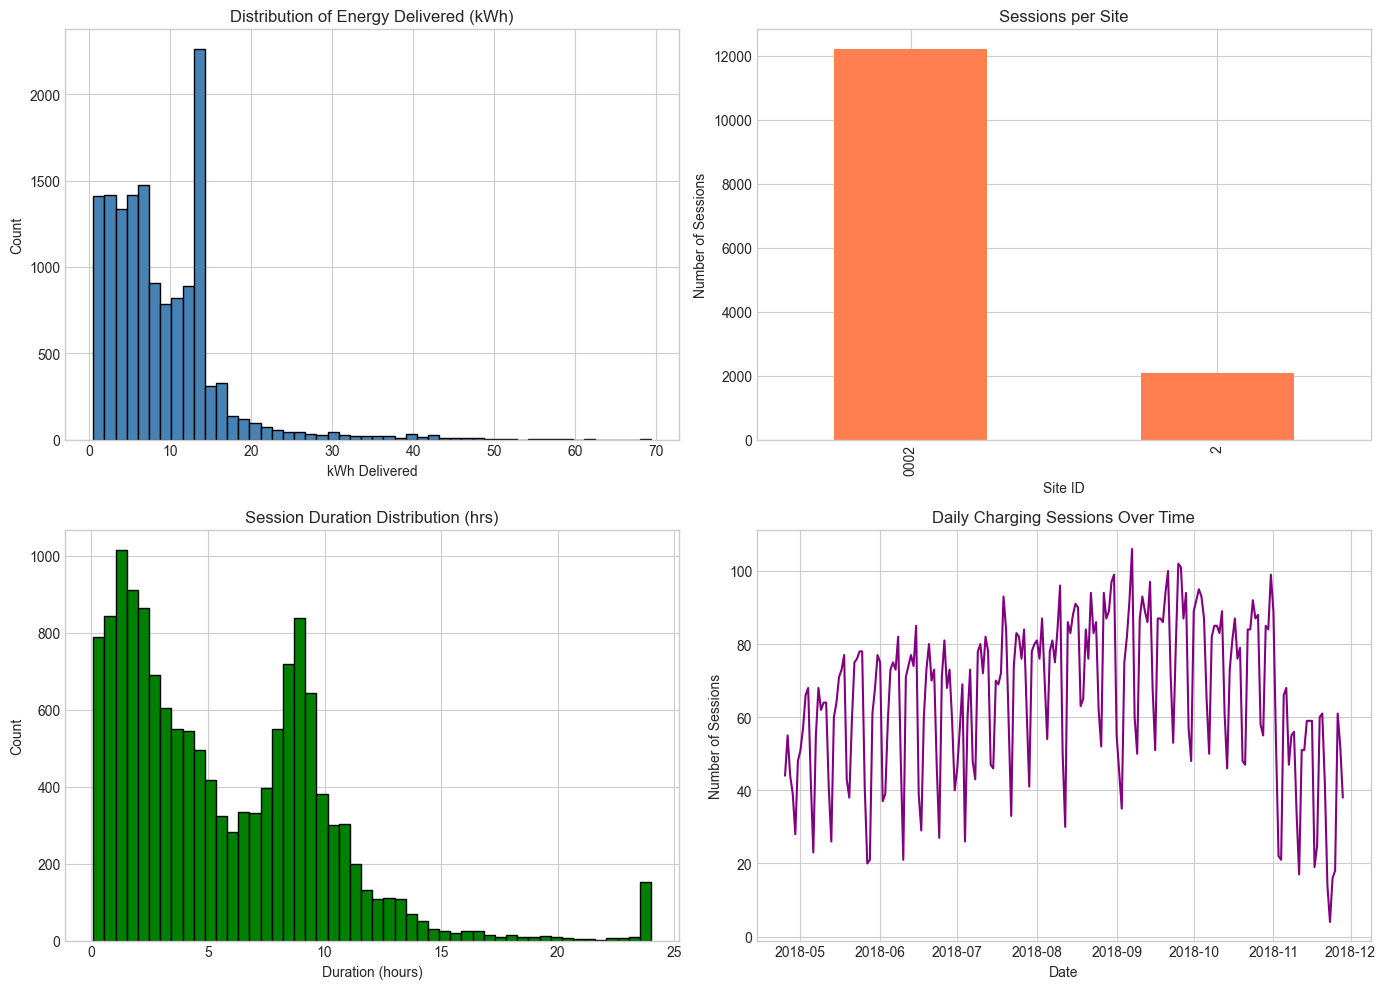

✅ EDA plots saved!


In [59]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Energy delivered distribution
axes[0,0].hist(sessions_df['kWhDelivered'].dropna(), bins=50, color='steelblue', edgecolor='black')
axes[0,0].set_title('Distribution of Energy Delivered (kWh)')
axes[0,0].set_xlabel('kWh Delivered')
axes[0,0].set_ylabel('Count')

# Plot 2: Sessions per site
if 'siteID' in sessions_df.columns:
    sessions_df['siteID'].value_counts().plot(kind='bar', ax=axes[0,1], color='coral')
    axes[0,1].set_title('Sessions per Site')
    axes[0,1].set_xlabel('Site ID')
    axes[0,1].set_ylabel('Number of Sessions')

# Plot 3: Connection duration
if 'connectionTime' in sessions_df.columns and 'disconnectTime' in sessions_df.columns:
    # sessions_df['connectionTime'] = pd.to_datetime(sessions_df['connectionTime'], utc=True)
    # sessions_df['disconnectTime'] = pd.to_datetime(sessions_df['disconnectTime'], utc=True)
    sessions_df['duration_hrs'] = (sessions_df['disconnectTime'] - sessions_df['connectionTime']).dt.total_seconds() / 3600
    axes[1,0].hist(sessions_df['duration_hrs'].clip(0, 24).dropna(), bins=50, color='green', edgecolor='black')
    axes[1,0].set_title('Session Duration Distribution (hrs)')
    axes[1,0].set_xlabel('Duration (hours)')
    axes[1,0].set_ylabel('Count')

# Plot 4: Sessions over time
if 'connectionTime' in sessions_df.columns:
    sessions_df['date'] = sessions_df['connectionTime'].dt.date
    daily_counts = sessions_df.groupby('date').size()
    daily_counts.plot(ax=axes[1,1], color='purple')
    axes[1,1].set_title('Daily Charging Sessions Over Time')
    axes[1,1].set_xlabel('Date')
    axes[1,1].set_ylabel('Number of Sessions')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved!")

## 3. Preprocessing & Hourly Aggregation

In [60]:
# Fix datetime columns before aggregation
datetime_cols = ['connectionTime', 'disconnectTime', 'doneChargingTime']

for col in datetime_cols:
    if col in sessions_df.columns:
        sessions_df[col] = pd.to_datetime(sessions_df[col], utc=True, errors='coerce')
        print(f"✅ {col} converted: {sessions_df[col].dtype}")

# Now run aggregation
df_hourly = aggregate_hourly(sessions_df)
print(f"✅ Hourly aggregation done: {df_hourly.shape}")
df_hourly.head()

✅ connectionTime converted: datetime64[ns, UTC]
✅ disconnectTime converted: datetime64[ns, UTC]
✅ doneChargingTime converted: datetime64[ns, UTC]
[Preprocessing] Aggregated sessions into 5215 hourly steps.
✅ Hourly aggregation done: (5215, 5)


,hour_dt,session_count,kwh_demand,dayofweek,hour
0,2018-04-25 11:00:00+00:00,1,7.932,2,11
1,2018-04-25 12:00:00+00:00,0,0.000,2,12
2,2018-04-25 13:00:00+00:00,2,15.270,2,13
3,2018-04-25 14:00:00+00:00,5,45.453,2,14
4,2018-04-25 15:00:00+00:00,15,69.505,2,15


## 4. Model Training & Tariff Optimization

In [61]:
# Split data
eval_steps = 752
df_train = df_hourly.iloc[:-eval_steps].copy()
df_eval = df_hourly.iloc[-eval_steps:].copy()
print(f"✅ Train size: {df_train.shape}, Eval size: {df_eval.shape}")

# Train Demand Agent
demand_agent = DemandPredictionAgent()
demand_agent.fit(df_train)
print("✅ Demand agent trained!")

# Tariff Agent
tariff_agent = TariffPricingAgent()

# MonitoringAgent
monitor = MonitoringLearningAgent()

# Loop through each eval row and generate predictions + tariffs
results = []
for _, row in df_eval.iterrows():
    dow = int(row['hour_dt'].dayofweek) if 'hour_dt' in df_eval.columns else int(row.name.dayofweek)
    hr  = int(row['hour_dt'].hour) if 'hour_dt' in df_eval.columns else int(row.name.hour)

    # Predict demand
    pred = demand_agent.predict(dayofweek=dow, hour=hr)

    # Calculate tariff
    tariff = tariff_agent.calculate_tariff(
        predicted_kwh=pred['predicted_kwh'],
        avg_kwh=demand_agent.global_mean_kwh
    )

    results.append({
        'hour_dt': row.get('hour_dt', row.name),
        'predicted_kwh': pred['predicted_kwh'],
        'tariff': tariff,
        'actual_kwh': row.get('total_kwh', np.nan)
    })

results_df = pd.DataFrame(results)
print(f"✅ Predictions & tariffs generated: {len(results_df)} steps")
results_df.head()

✅ Train size: (4463, 5), Eval size: (752, 5)
[DemandPredictionAgent] Trained on 4463 hourly samples. Global avg kwh: 25.77
✅ Demand agent trained!
✅ Predictions & tariffs generated: 752 steps


,hour_dt,predicted_kwh,tariff,actual_kwh
0,2018-10-28 10:00:00+00:00,1.057744,0.238013,NaN
1,2018-10-28 11:00:00+00:00,0.597654,0.237790,NaN
2,2018-10-28 12:00:00+00:00,0.929462,0.237951,NaN
3,2018-10-28 13:00:00+00:00,1.133522,0.238050,NaN
4,2018-10-28 14:00:00+00:00,9.043115,0.241886,NaN


## 5. Simulation & KPIs

In [62]:
with open('c:/projects_antig/src/evaluator.py', 'r') as f:
    lines = f.readlines()

for i, line in enumerate(lines, 1):
    print(f"{i}: {line}", end='')

1: # src/evaluator.py
2: 
3: """
4: Evaluation metrics and plotting utilities for the EV Charging Optimization System.
5: Computes KPIs (Revenue Lift, Utilization, Satisfaction, MAE, RMSE) and exports results.
6: """
7: 
8: import pandas as pd
9: import numpy as np
10: import matplotlib.pyplot as plt
11: 
12: def compute_kpis(df_results: pd.DataFrame, base_price_per_kwh: float = 0.25) -> dict:
13:     """
14:     Computes system and operational KPIs.
15:     
16:     Args:
17:         df_results (pd.DataFrame): Simulation output logs.
18:         base_price_per_kwh (float): Price for the flat-rate baseline.
19:         
20:     Returns:
21:         dict: A dictionary of calculated KPI metrics.
22:     """
23:     actual_kwh = df_results["actual_kwh"]
24:     predicted_kwh = df_results["predicted_kwh"]
25:     tariff_price = df_results["tariff_price"]
26:     utilization = df_results["utilization"]
27:     satisfaction = df_results["satisfaction"]
28:     
29:     total_energy = actual_

In [63]:
# Build kpi_df with exact column names evaluator.py expects
kpi_df = results_df.copy()
kpi_df['actual_kwh'] = df_eval['kwh_demand'].values
kpi_df = kpi_df.rename(columns={'tariff': 'tariff_price'})

# Add utilization = actual / predicted (capped at 1)
kpi_df['utilization'] = (
    kpi_df['actual_kwh'] / kpi_df['predicted_kwh'].replace(0, np.nan)
).clip(0, 1).fillna(0)

# Add satisfaction = inverse of price deviation from base rate
kpi_df['satisfaction'] = (
    1 - ((kpi_df['tariff_price'] - 0.25) / 0.25).abs()
).clip(0, 1)

print("✅ kpi_df columns:", kpi_df.columns.tolist())

# Compute KPIs
kpis = compute_kpis(kpi_df)
print("\n📊 Key Performance Indicators:")
for k, v in kpis.items():
    print(f"  {k}: {v}")

✅ kpi_df columns: ['hour_dt', 'predicted_kwh', 'tariff_price', 'actual_kwh', 'utilization', 'satisfaction']

📊 Key Performance Indicators:
  total_energy_kwh: 13388.58864092884
  flat_revenue: 3347.14716023221
  dynamic_revenue: 3577.6154654109278
  net_revenue_lift: 230.46830517871786
  pct_revenue_lift: 6.885514563474676
  avg_utilization: 0.3753695430922433
  avg_satisfaction: 0.9631471374860815
  mae_demand: 17.586859705941635
  rmse_demand: 27.472475786059505


In [64]:
import os
os.makedirs('notebooks', exist_ok=True)
plot_simulation_results(kpi_df, save_path='notebooks/simulation_report.png')

[Evaluator] Saved simulation report chart to notebooks/simulation_report.png


## 6. Full Simulation Run

In [65]:
from main import run_simulation
run_simulation()
print("✅ Full simulation complete!")

[DataLoader] Loaded 1706 stations from CSV.
[DataLoader] Reading and repairing ACN-Data JSON file...
[DataLoader] Loaded 14299 charging sessions from JSON.
[Preprocessing] Aggregated sessions into 5215 hourly steps.
[Main] Split data: Train=4463 hours, Eval=752 hours.
[DemandPredictionAgent] Trained on 4463 hourly samples. Global avg kwh: 25.77

      SIMULATION RESULTS COMPARISON SUMMARY
Evaluation Hours            : 752
Total Energy Delivered      : 13388.59 kWh
Static Revenue ($0.25/kWh)  : $3347.15
Dynamic Tariff Revenue      : $3397.05
Net Revenue Lift            : $49.90 (1.49%)
Average Grid Utilization    : 0.11
Average User Satisfaction   : 0.97
Demand Forecasting MAE      : 17.59 kWh
Demand Forecasting RMSE     : 27.47 kWh

[Evaluator] Saved simulation report chart to C:/projects_antig/notebooks/simulation_report.png
[Main] Copied report chart to brain artifacts directory.
✅ Full simulation complete!


In [66]:
from sklearn.metrics import r2_score
r2 = r2_score(kpi_df['actual_kwh'], kpi_df['predicted_kwh'])
print(f"R² Score: {r2}")

R² Score: 0.29285325522130046


In [67]:
base_price = 15  # ₹15/kWh as per project requirement
flat_revenue = kpi_df['actual_kwh'].sum() * base_price
dynamic_revenue = (kpi_df['actual_kwh'] * kpi_df['tariff_price']).sum()
revenue_gain = ((dynamic_revenue - flat_revenue) / flat_revenue) * 100
print(f"Revenue Gain % vs ₹15/kWh baseline: {revenue_gain:.2f}%")

Revenue Gain % vs ₹15/kWh baseline: -98.22%


In [68]:
off_peak = kpi_df[kpi_df['utilization'] < 0.30]
print(f"Off-peak hours: {len(off_peak)}")
print(f"Avg tariff in off-peak: {off_peak['tariff_price'].mean():.4f}")

Off-peak hours: 411
Avg tariff in off-peak: 0.2459
